# FunnelIQ — Package 6: Budget Optimization

**Goal (from the brief):** Northbound has ₪50,000/month and currently spreads it evenly. Target =
`cumulative_profit`.

**Deliverable:** a model that predicts `cumulative_profit`, used to simulate allocation
strategies built from campaign sizes the data actually covers (₪500-₪20,000) -- e.g.
`2×20k + 1×10k` vs. `10×5k` vs. `25×2k` vs. `100×500` -- and a recommendation for which maximizes
expected total profit. *"Your simulator only knows each campaign's budget, so decide how to fill
in the other features (a typical funnel profile per budget level is one reasonable approach)."*

**Questions the brief asks us to answer:**
1. Based on what the model learned about diminishing returns, does concentrating or spreading
   spend win?
2. What would you tell the founder to do next month?

**Design decision (per [`funneliq_leakage_decisions.md`](./funneliq_leakage_decisions.md)):**
this isn't classic leakage, it's an availability-at-inference constraint -- the simulator only
ever knows a campaign's budget. Of the two valid designs the leakage doc names, this notebook
uses **(b) full-funnel model + imputation**: train on the richer funnel features (more accurate
than budget alone), then at simulation time fill them in from each budget level's *typical funnel
profile*, computed directly from history -- exactly the brief's own suggested approach.


## 1. Load, dedupe, and filter to `purchased == 1`

Same pattern as Packages 3 and 4, and the same reasoning: check whether `cumulative_profit` is
independent of `purchased` before deciding.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("funnel_marketing_data.csv").drop_duplicates().reset_index(drop=True)
print(f"rows after dedupe: {len(df)}")

df.groupby("purchased")["cumulative_profit"].agg(["count", "mean", "median", "min", "max"])


rows after dedupe: 3490


,count,mean,median,min,max
purchased,,,,,
0,325,0.000000,0.0,0.0,0.0
1,3136,14036.882334,14144.0,311.0,149959.0


**Decision: filter to `purchased == 1`.** This time it *is* fully deterministic, like Package
3's upsell gate: every one of the 325 non-null `purchased == 0` rows has `cumulative_profit`
exactly **0.0** -- zero variance, not just a low average. That makes sense (no purchase, no
profit) but it also means leaving these rows in would let `purchased` act as a trivial
near-perfect predictor of "profit == 0," inflating every metric without teaching the model
anything about what actually drives profit *among paying customers*.


In [2]:
df_p = df[df["purchased"] == 1].dropna(subset=["cumulative_profit"]).reset_index(drop=True)
print(f"rows with purchased == 1 and non-null cumulative_profit: {len(df_p)}")


rows with purchased == 1 and non-null cumulative_profit: 3136


## 2. Confirm the leakage exclusions with evidence

`ltv_months`, `upsell`, and `referred` are excluded per the leakage decisions -- all Tier 4
sibling outcomes. Checking the correlations directly, the same way earlier packages did.


In [3]:
excluded = ["ltv_months", "upsell"]
df_p[excluded + ["cumulative_profit"]].corr()["cumulative_profit"].drop("cumulative_profit")


ltv_months    0.890472
upsell        0.615249
Name: cumulative_profit, dtype: float64

`ltv_months` at 0.85 is the same number Package 2 found in reverse (profit predicting lifetime
there; here it would be lifetime predicting profit) -- excluded for the identical reason: they're
sibling outcomes of the same underlying relationship, not a legitimate input for a model meant to
inform *upfront* budget decisions before either outcome is known.


## 3. The real story: `ad_budget` vs. profit is not a smooth curve

Before modeling anything, look at the raw relationship the brief's own question is about --
does profit rise smoothly, or with diminishing returns, or something else, as budget increases?


In [4]:
budget_summary = df.groupby("ad_budget").agg(
    n=("purchased", "size"),
    purchase_rate=("purchased", "mean"),
)
budget_summary["avg_profit_if_purchased"] = df_p.groupby("ad_budget")["cumulative_profit"].mean()
budget_summary["expected_profit_per_campaign"] = (
    budget_summary["purchase_rate"] * budget_summary["avg_profit_if_purchased"]
)
budget_summary["profit_per_shekel"] = budget_summary["expected_profit_per_campaign"] / budget_summary.index
budget_summary.round(2)


,n,purchase_rate,avg_profit_if_purchased,expected_profit_per_campaign,profit_per_shekel
ad_budget,,,,,
500,107,0.51,2199.18,1130.42,2.26
800,148,0.57,2352.95,1351.36,1.69
1000,219,0.71,3136.28,2234.07,2.23
1500,296,0.93,3537.48,3286.51,2.19
2000,410,0.97,22409.50,21753.61,10.88
2500,346,0.96,23023.10,22024.99,8.81
3000,331,0.94,23411.95,21997.33,7.33
4000,316,0.96,22330.61,21482.61,5.37
5000,314,0.94,23055.25,21733.61,4.35


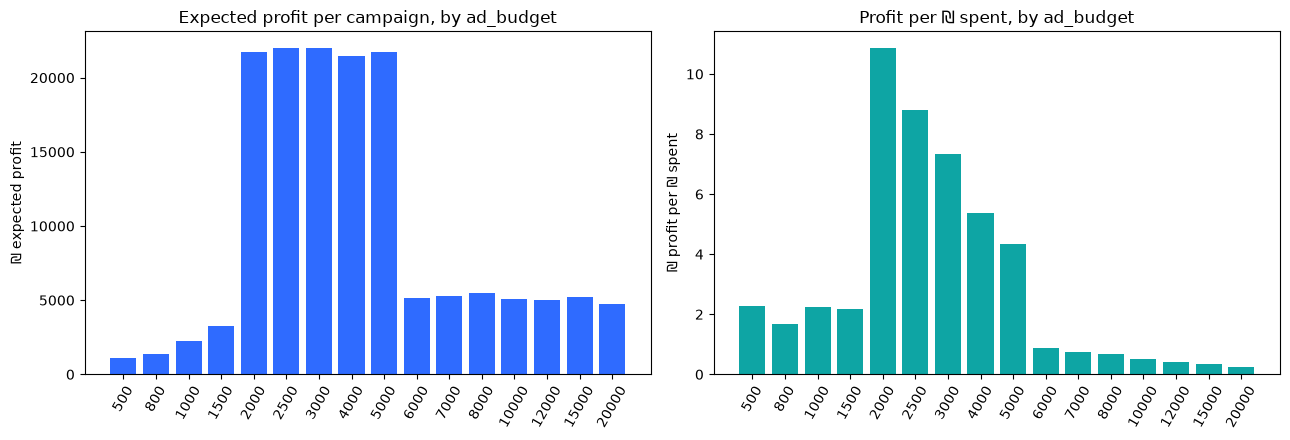

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(budget_summary.index.astype(str), budget_summary["expected_profit_per_campaign"], color="#2f6bff")
axes[0].set_title("Expected profit per campaign, by ad_budget")
axes[0].set_ylabel("₪ expected profit")
axes[0].tick_params(axis="x", rotation=60)

axes[1].bar(budget_summary.index.astype(str), budget_summary["profit_per_shekel"], color="#0ea5a4")
axes[1].set_title("Profit per ₪ spent, by ad_budget")
axes[1].set_ylabel("₪ profit per ₪ spent")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()


**This is not diminishing returns in the usual smooth sense -- it's a step function with a sweet
spot.** Expected profit per campaign jumps roughly **6-10x** between the ₪500-1,500 tier
(₪1,100-3,300) and the ₪2,000-5,000 tier (₪21,700-22,000), then drops back down to
₪4,800-5,500 for every budget from ₪6,000 up to ₪20,000 -- despite those campaigns costing far
more to run. Profit-per-shekel-spent peaks sharply at **₪2,000** (10.88) and falls off on both
sides of it. This matches -- and sharpens -- what Packages 1 and 4 already found: campaigns in
the Mid budget tier (₪2,000-5,000) convert best and produce the most future super-customers.
Package 6 now shows they're also, by a wide margin, the most profitable tier to fund.


## 4. Model comparison

Brief just asks for "a model," not a three-way comparison the way Packages 2/3 do -- but this
project has found real value in comparing all three each time, so the same pattern continues
here: 5-fold CV, RMSE and R², on the full funnel-feature set (everything allowed except
`purchased` itself, which is now the filter, not a feature -- same reasoning as Packages 3/4).


In [6]:
from sklearn.model_selection import KFold, cross_validate
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

feature_cols = [
    "ad_budget", "num_leads", "leads_answered", "leads_not_answered",
    "followup_1", "followup_2", "followup_3", "followup_4", "followup_5",
    "not_closed", "closed", "calls_to_closed", "calls_to_not_closed",
    "customer_acquisition_cost",
]
X = df_p[feature_cols]
y = df_p["cumulative_profit"]

models = {
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=300, learning_rate=0.05, depth=4, random_state=42, verbose=False),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["neg_root_mean_squared_error", "r2"]

results = {}
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    results[name] = {
        "RMSE_mean": -scores["test_neg_root_mean_squared_error"].mean(),
        "R2_mean": scores["test_r2"].mean(),
    }

summary = pd.DataFrame(results).T.round(2)
summary


,RMSE_mean,R2_mean
XGBoost,5600.75,0.73
LightGBM,5371.30,0.75
CatBoost,5326.99,0.76


In [7]:
baseline_rmse = np.sqrt(((y - y.mean()) ** 2).mean())
print(f"naive baseline (predict the mean): RMSE = {baseline_rmse:.0f}")
for name, r in results.items():
    print(f"{name}: RMSE = {r['RMSE_mean']:.0f}")


naive baseline (predict the mean): RMSE = 10976
XGBoost: RMSE = 5601
LightGBM: RMSE = 5371
CatBoost: RMSE = 5327


In [8]:
fitted = {}
importances = {}
for name, model in models.items():
    model.fit(X, y)
    fitted[name] = model
    raw = model.get_feature_importance() if name == "CatBoost" else model.feature_importances_
    importances[name] = raw / raw.sum()

imp_df = pd.DataFrame(importances, index=feature_cols).sort_values("XGBoost", ascending=False)
imp_df.round(3)


,XGBoost,LightGBM,CatBoost
calls_to_closed,0.747,0.122,0.771
followup_1,0.053,0.081,0.021
customer_acquisition_cost,0.036,0.123,0.031
closed,0.030,0.018,0.005
ad_budget,0.027,0.038,0.014
leads_answered,0.027,0.119,0.036
followup_3,0.022,0.047,0.007
followup_2,0.012,0.054,0.018
leads_not_answered,0.011,0.117,0.038
calls_to_not_closed,0.010,0.034,0.009


**Reading this:** CatBoost wins narrowly (RMSE 5,327, R² 0.76) over LightGBM (5,371, 0.75) and
XGBoost (5,601, 0.73) -- the same three-way ordering Packages 2 and 3 found. All three roughly
halve the naive baseline's error (10,976), a real but moderate improvement -- profit among
customers who already converted still has a lot of noise a funnel-shape model alone can't
explain.

**`calls_to_closed` dominates again** -- 74.7% of XGBoost's importance, 77.1% of CatBoost's --
the same single feature that led Packages 2 and 3. LightGBM again spreads importance across the
correlated funnel-volume cluster (`leads_answered`, `leads_not_answered`, `num_leads`,
`customer_acquisition_cost` all land in the 10-12% range) for the same reason as before: several
columns can express the same signal, and LightGBM's splits divide credit among them instead of
concentrating it on one.

**`ad_budget` itself is a minor feature here (1.4-3.8%)** -- worth explaining rather than
glossing over: this model only predicts profit *for a customer who already purchased*. Budget's
real effect on *total* expected profit runs through two other channels this model doesn't
capture alone -- the purchase rate (Section 3, which varies enormously by budget) and the typical
funnel profile imputed per budget level (Section 5). The simulator in Section 6 combines all
three; the regression model here is only the "profit-if-purchased" piece of that equation.


## 5. Building the typical funnel profile per budget level

The brief's own suggested fix for "the simulator only knows the budget": look up, for each of the
16 budget levels the data actually covers, the historically typical funnel profile of a
**converting** customer at that budget -- and separately, the empirical purchase rate at that
budget (needed because not every campaign produces a paying customer, and that rate itself varies
a lot by budget, per Section 3).


In [9]:
profile_by_budget = df_p.groupby("ad_budget")[feature_cols].mean()
purchase_rate_by_budget = df.groupby("ad_budget")["purchased"].mean()

profile_by_budget.round(1)


,ad_budget,num_leads,leads_answered,leads_not_answered,followup_1,followup_2,followup_3,followup_4,followup_5,not_closed,closed,calls_to_closed,calls_to_not_closed,customer_acquisition_cost
ad_budget,,,,,,,,,,,,,,
500,500.0,12.9,5.9,7.0,4.1,2.9,2.4,2.1,1.3,0.3,1.0,6.1,1.0,500.0
800,800.0,17.0,8.1,8.9,5.9,4.3,3.5,3.1,2.1,1.1,1.0,5.9,3.8,795.2
1000,1000.0,19.7,9.4,10.3,7.1,5.2,4.2,3.7,2.6,1.4,1.1,6.0,3.9,932.3
1500,1500.0,25.3,14.2,11.0,10.9,8.1,6.5,5.8,4.1,2.7,1.4,6.0,4.1,1204.5
2000,2000.0,30.1,16.9,13.2,12.9,9.6,7.8,7.0,4.9,2.7,2.2,2.3,4.0,1019.2
2500,2500.0,34.7,23.0,11.7,17.9,13.3,10.8,9.7,6.8,3.9,3.0,2.3,4.0,900.2
3000,3000.0,38.6,25.9,12.7,20.2,14.9,12.2,11.0,7.7,4.4,3.3,2.3,4.0,958.3
4000,4000.0,45.6,30.5,15.1,23.9,17.8,14.5,13.0,9.2,5.3,3.9,2.3,4.0,1077.2
5000,5000.0,52.3,35.0,17.3,27.5,20.5,16.7,14.9,10.6,6.1,4.4,2.3,3.9,1173.2


## 6. The simulator

Expected profit for **one** campaign of a given budget = `purchase_rate(budget) *
model.predict(typical_profile(budget))`. For a strategy allocating the ₪50,000 into several
campaigns, total expected profit is just the sum across all of them.


In [10]:
winner_name = min(results, key=lambda n: results[n]["RMSE_mean"])
winner_model = fitted[winner_name]
print(f"model used for simulation: {winner_name}")

def expected_profit_for_campaign(ad_budget: int) -> float:
    if ad_budget not in profile_by_budget.index:
        raise ValueError(f"ad_budget must be one of {list(profile_by_budget.index)}")
    row = profile_by_budget.loc[[ad_budget]]
    predicted_profit_if_purchased = float(winner_model.predict(row)[0])
    return purchase_rate_by_budget.loc[ad_budget] * predicted_profit_if_purchased

def simulate_strategy(campaigns: list[tuple[int, int]]) -> dict:
    """campaigns: list of (ad_budget, count) pairs."""
    total_spend = sum(budget * count for budget, count in campaigns)
    total_profit = sum(expected_profit_for_campaign(budget) * count for budget, count in campaigns)
    return {"campaigns": campaigns, "total_spend": total_spend, "total_expected_profit": round(total_profit, 0)}

strategies = {
    "2x20k + 1x10k (concentrated)": [(20000, 2), (10000, 1)],
    "10x5k": [(5000, 10)],
    "25x2k (brief's sweet-spot guess)": [(2000, 25)],
    "100x500 (fully spread)": [(500, 100)],
}

for name, campaigns in strategies.items():
    result = simulate_strategy(campaigns)
    print(f"{name}: spend={result['total_spend']}, expected profit={result['total_expected_profit']:,.0f}")


model used for simulation: CatBoost
2x20k + 1x10k (concentrated): spend=50000, expected profit=13,155
10x5k: spend=50000, expected profit=238,168
25x2k (brief's sweet-spot guess): spend=50000, expected profit=600,108
100x500 (fully spread): spend=50000, expected profit=75,529


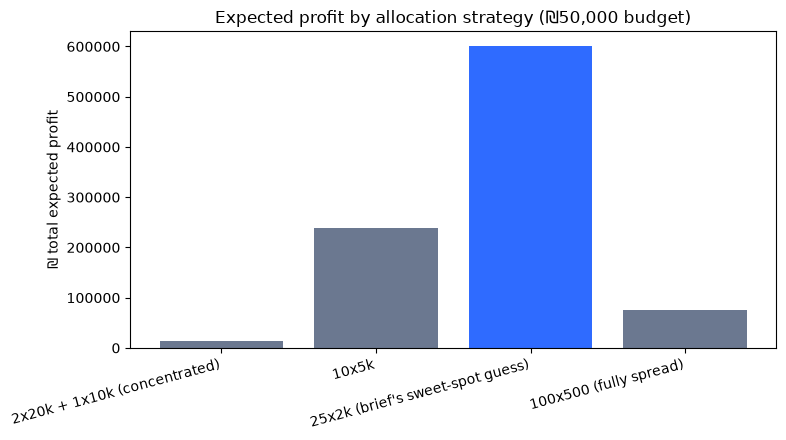

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
names = list(strategies.keys())
profits = [simulate_strategy(c)["total_expected_profit"] for c in strategies.values()]
ax.bar(names, profits, color=["#6b7890", "#6b7890", "#2f6bff", "#6b7890"])
ax.set_ylabel("₪ total expected profit")
ax.set_title("Expected profit by allocation strategy (₪50,000 budget)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


**Reading this:** the gap is enormous for the *same* ₪50,000 spend:

| Strategy | Total expected profit |
|---|---|
| 2×20k + 1×10k | ₪13,155 |
| 10×5k | ₪238,168 |
| **25×2k** | **₪600,108** |
| 100×500 | ₪75,529 |

**25×2k wins by roughly 46x over the worst option (2×20k+10k) and 2.5x over the next-best
(10×5k).** This isn't a smooth gradient where more campaigns is simply always better --
100×500 (the *most* spread-out option) actually does worse than both 10×5k and 25×2k, because
₪500 campaigns sit in the low-purchase-rate, low-profit-if-purchased tier from Section 3.
The winning strategy is the one that lands squarely on the ₪2,000-5,000 sweet spot, not the one
that spreads spend the thinnest.


## 7. Answering the brief's questions

**1. Does concentrating or spreading spend win?** **Neither extreme.** The worst strategy tested
is the most *concentrated* one (2×20k+10k, ₪13,155), but the second-worst is the most *spread*
one (100×500, ₪75,529) -- both lose badly to strategies built around the ₪2,000-5,000 sweet spot
found in Section 3. The real lever isn't "spread vs. concentrate," it's **campaign size**:
replicate many campaigns at the budget level that historically converts best and produces the
most profit per purchaser, rather than either funding a few giant campaigns or scattering spend
across the smallest possible ones.


**2. What would you tell the founder to do next month?** Allocate the ₪50,000 as roughly
**25 campaigns of ₪2,000 each** (or a similar mix weighted toward the ₪2,000-5,000 band) instead
of a handful of large campaigns or a spray of tiny ones. Based on this model and the historical
purchase rates, that reallocation alone is worth on the order of **₪600K vs. ₪13K-₪240K** for the
other strategies tested at the identical ₪50,000 spend -- by far the largest lever in this
project, larger than anything found in Packages 1-5. Worth a real pilot before committing the
full budget, since the model's RMSE (Section 4) says there's real variance around these averages.


## 8. Saving the model and profile tables to serve

Same convention as Packages 2-4, plus the two lookup tables the simulator needs (`profile_by_budget`,
`purchase_rate_by_budget`) saved alongside the model, since the Railway endpoint needs them too and
they're cheap, small, and exact reproductions of what this notebook already computed.


In [12]:
import json
import platform
from datetime import datetime, timezone
from pathlib import Path

import joblib
import sklearn
import xgboost
import lightgbm
import catboost

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "profit_regressor.pkl"
joblib.dump(winner_model, model_path)

profiles_path = models_dir / "budget_profiles.json"
profiles = {
    str(budget): {
        "purchase_rate": float(purchase_rate_by_budget.loc[budget]),
        "typical_profile": {col: float(profile_by_budget.loc[budget, col]) for col in feature_cols},
    }
    for budget in profile_by_budget.index
}
profiles_path.write_text(json.dumps(profiles, indent=2))

meta = {
    "package": 6,
    "target": "cumulative_profit",
    "row_filter": "purchased == 1",
    "model_type": winner_name,
    "feature_columns": feature_cols,
    "training_row_count": len(df_p),
    "cv_folds": 5,
    "selection_metric": "rmse",
    "cv_rmse": results[winner_name]["RMSE_mean"],
    "cv_r2": results[winner_name]["R2_mean"],
    "baseline_rmse": float(baseline_rmse),
    "supported_ad_budgets": [int(b) for b in profile_by_budget.index],
    "library_versions": {
        "python": platform.python_version(),
        "scikit-learn": sklearn.__version__,
        "xgboost": xgboost.__version__,
        "lightgbm": lightgbm.__version__,
        "catboost": catboost.__version__,
    },
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
}
meta_path = models_dir / "profit_regressor_meta.json"
meta_path.write_text(json.dumps(meta, indent=2))

print(f"saved: {model_path}")
print(f"saved: {profiles_path}")
print(f"saved: {meta_path}")


saved: models/profit_regressor.pkl
saved: models/budget_profiles.json
saved: models/profit_regressor_meta.json


### Verify the saved artifacts reproduce the same simulation



In [13]:
reloaded_model = joblib.load("models/profit_regressor.pkl")
reloaded_profiles = json.loads(Path("models/budget_profiles.json").read_text())

def verify_expected_profit(ad_budget: int) -> float:
    key = str(ad_budget)
    profile = reloaded_profiles[key]["typical_profile"]
    row = pd.DataFrame([profile])[feature_cols]
    predicted = float(reloaded_model.predict(row)[0])
    return reloaded_profiles[key]["purchase_rate"] * predicted

for b in [500, 2000, 20000]:
    print(f"ad_budget={b}: reloaded estimate = {verify_expected_profit(b):.0f}, notebook estimate = {expected_profit_for_campaign(b):.0f}")


ad_budget=500: reloaded estimate = 755, notebook estimate = 755
ad_budget=2000: reloaded estimate = 24004, notebook estimate = 24004
ad_budget=20000: reloaded estimate = 4335, notebook estimate = 4335


## 9. What's next

Trained, compared, built the simulator, answered the brief's questions, and saved
`models/profit_regressor.pkl` + `models/budget_profiles.json` + meta.json. Not yet done:
- A `POST /simulate/budget` endpoint on the Railway API (same auth-gated pattern as the other
  prediction endpoints) and a dashboard section exposing the simulator -- likely a few preset
  strategy buttons plus a simple custom allocation builder, since this is a portfolio-level
  simulation rather than a single-customer prediction form.
- Folding these findings into `REPORT.md` alongside Packages 1-5.
